<a id="top"></a>
# IMAGE - Nâng cao: Phát hiện cạnh và Phân tích đặc trưng cục bộ

## Mục lục
1. [Mục tiêu bài toán](#1-muc-tieu)
2. [Cơ sở lý thuyết: Kỹ thuật phát hiện cạnh](#2-ly-thuyet-canh)
3. [Cơ sở lý thuyết: Kiểm định phương sai ANOVA](#3-ly-thuyet-anova)
4. [Mã nguồn thực thi](#4-code)
5. [Phân tích và Thảo luận kết quả](#5-phan-tich)

---

<a id="1-muc-tieu"></a>
## 1. Mục tiêu bài toán
Từ kết quả của phần phân tích PCA & t-SNE, ta đã biết các thuật toán học máy không thể phân loại động vật dựa trên giá trị pixel màu sắc (do bị nhiễu bởi phông nền và ánh sáng). 

Vì vậy, ở bước này, ta sẽ thay đổi góc nhìn: Chuyển từ việc phân tích **"Màu sắc" (Color)** sang phân tích **"Hình thái và Cấu trúc" (Shape & Structure)**. Thông qua các bộ lọc phát hiện cạnh, ta sẽ lược bỏ toàn bộ màu nền, chỉ giữ lại các đường nét phác thảo con vật. 
Mục tiêu cốt lõi: 
* Trích xuất mật độ cạnh (Edge Density) bằng 3 phương pháp: Sobel, Prewitt, Canny.
* Sử dụng kiểm định thống kê ANOVA để trả lời câu hỏi: *"Mật độ đường viền của con chó có thực sự khác biệt so với con nhện hay con chim không?"*.

---

<a id="2-ly-thuyet-canh"></a>
## 2. Cơ sở lý thuyết: Kỹ thuật phát hiện cạnh (Edge Detection)

Cạnh (Edge) trong xử lý ảnh là những vùng mà cường độ sáng (pixel value) thay đổi đột ngột. Để tìm ra các cạnh này, ta sử dụng các bộ lọc (filters) quét qua bức ảnh.

### 2.1. Phương pháp Gradient (Sobel & Prewitt)
Hai phương pháp này hoạt động bằng cách tính đạo hàm bậc 1 của bức ảnh theo chiều dọc và chiều ngang. Đạo hàm càng lớn chứng tỏ sự thay đổi độ sáng càng gắt (đó chính là cạnh).

<p align="center">
  <img src="https://www.researchgate.net/profile/Sarifuddin-Madenda/publication/311605340/figure/fig2/AS:542615251505152@1506380965005/Kernel-of-a-Prewitt-operator-and-b-Sobel-operators.png" alt="Prewitt and Sobel Kernels" width="550">
  <br>
  <i>Hình: Ma trận nhân (Kernel) của phương pháp Prewitt (a) và Sobel (b).</i>
</p>

* **Prewitt:** Sử dụng các ma trận nhân cơ bản, đánh giá đều các điểm lân cận. Nó hoạt động tốt trên các ảnh ít nhiễu.
* **Sobel:** Tương tự Prewitt nhưng ma trận nhân của Sobel đặt trọng số (weight = 2) cao hơn cho điểm ảnh ở vị trí trung tâm. Điều này giúp Sobel làm mờ nhiễu tốt hơn và cho ra đường viền sắc nét hơn Prewitt một chút.
* **Tham số (Hyperparameter):** Ta sẽ thử nghiệm với 2 ngưỡng cắt (Threshold = 50 và 100). Những điểm ảnh có cường độ Gradient vượt ngưỡng này mới được công nhận là cạnh.

### 2.2. Phương pháp Canny
Canny không chỉ là một bộ lọc đơn giản, nó là một thuật toán đa bước phức tạp và được xem là "State-of-the-art" trong phát hiện cạnh truyền thống.

<p align="center">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRt885a140jycqpN5F0Q0gDiCN83eM88ChLWQ&s" alt="Canny Edge Detection Example" width="500">
  <br>
  <i>Hình: Minh họa khả năng khử nhiễu và bắt đường viền của thuật toán Canny.</i>
</p>

* **Quy trình 4 bước:** Làm mờ nhiễu bằng Gaussian -> Tính Gradient -> Triệt tiêu điểm không cực đại (Làm mỏng cạnh) -> Lọc ngưỡng kết trễ (Hysteresis Thresholding).
* **Tham số (Hyperparameters):** Canny sử dụng 2 ngưỡng (MinVal, MaxVal). Đường nét có cường độ lớn hơn MaxVal chắc chắn là cạnh. Nằm dưới MinVal bị loại bỏ. Nằm ở giữa sẽ được giữ lại nếu nó nối liền với một cạnh chắc chắn. Ta sẽ test 2 cấu hình: Nhạy (50, 150) và Ít nhạy (100, 200).

### 2.3. Mật độ cạnh (Edge Density)
Sau khi trích xuất được ma trận cạnh (chỉ gồm các pixel đen và trắng), ta cần chuyển nó thành một con số định lượng để đưa vào mô hình thống kê. Công thức tính toán rất đơn giản:

$$Edge\ Density = \frac{\text{Số lượng pixel cạnh (màu trắng)}}{\text{Tổng số pixel của toàn bộ ảnh}}$$

---

<a id="3-ly-thuyet-anova"></a>
## 3. Cơ sở lý thuyết: Kiểm định phương sai ANOVA (One-Way ANOVA)

Khi đã tính được Mật độ cạnh cho hàng ngàn bức ảnh, làm sao ta biết được các loài động vật có mật độ cạnh khác nhau hay không? Ta không thể so sánh bằng mắt, mà phải dùng bài toán thống kê **Phân tích phương sai một chiều (One-Way ANOVA)**.

ANOVA giúp so sánh giá trị trung bình của từ 3 nhóm trở lên (ở đây ta có 10 lớp động vật).
* **Giả thuyết H0 (Null Hypothesis):** $\mu_1 = \mu_2 = ... = \mu_{10}$ (Mật độ cạnh trung bình của 10 loài động vật là bằng nhau. Tức là đặc trưng này không có tác dụng phân loại).
* **Giả thuyết H1 (Alternative Hypothesis):** Tồn tại ít nhất một loài động vật có mật độ cạnh trung bình khác biệt đáng kể so với các loài còn lại.

**Quy tắc ra quyết định:** Ta sử dụng mức ý nghĩa $\alpha = 0.05$. Sau khi chạy thuật toán, nếu giá trị **P-value < 0.05**, ta có đủ bằng chứng thống kê để bác bỏ giả thuyết $H_0$. Khi đó ta kết luận: Đặc trưng cạnh có khả năng giúp phân biệt các lớp.

# <a id="4-code"></a>
# 4. Mã nguồn thực thi

[MAIN] Nạp Dataset...
[INFO] Bắt đầu trích xuất đặc trưng Cạnh trên mẫu 1000 ảnh...
   -> Đã xử lý 200/1000 ảnh
   -> Đã xử lý 400/1000 ảnh
   -> Đã xử lý 600/1000 ảnh
   -> Đã xử lý 800/1000 ảnh
   -> Đã xử lý 1000/1000 ảnh
[SUCCESS] Trích xuất Edge Density hoàn tất!
[STATUS] Analysis: Edge Detection & Density - Success

[MAIN] Vẽ biểu đồ Boxplot so sánh phân phối giữa các lớp...


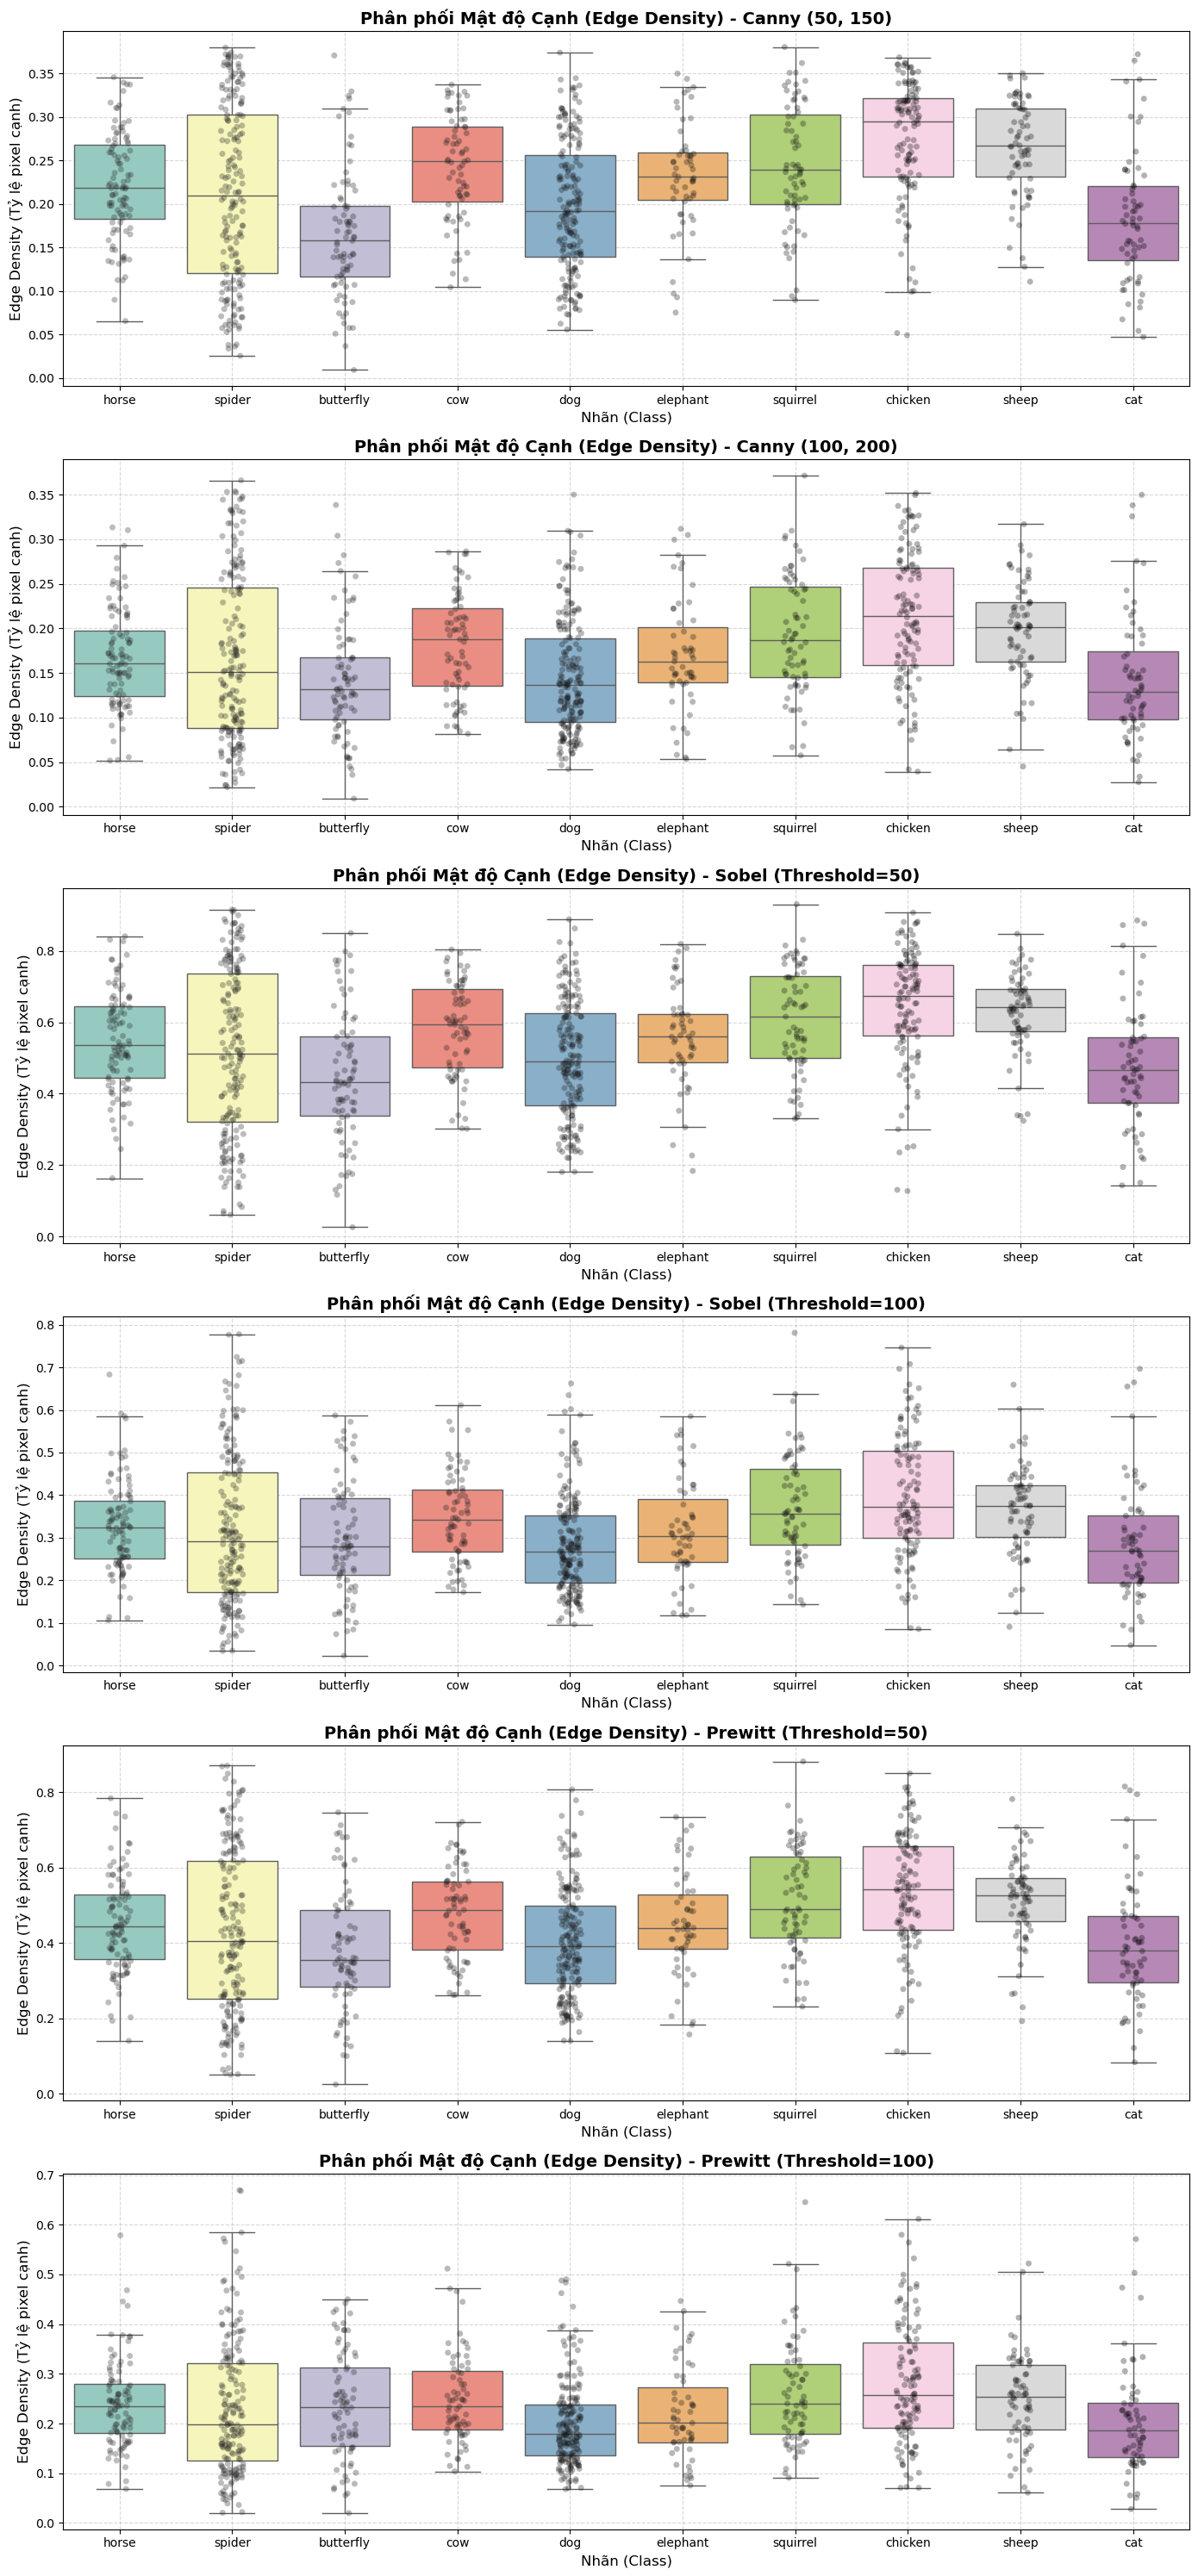


[STATISTIC] Bắt đầu kiểm định ANOVA (Mức ý nghĩa alpha = 0.05)...
   -> Canny (50, 150): P-Value = 9.60e-30 | Thống kê F = 19.15 | Có sự khác biệt
   -> Canny (100, 200): P-Value = 5.09e-19 | Thống kê F = 12.55 | Có sự khác biệt
   -> Sobel (Threshold=50): P-Value = 2.57e-21 | Thống kê F = 13.95 | Có sự khác biệt
   -> Sobel (Threshold=100): P-Value = 1.20e-12 | Thống kê F = 8.70 | Có sự khác biệt
   -> Prewitt (Threshold=50): P-Value = 2.11e-17 | Thống kê F = 11.57 | Có sự khác biệt
   -> Prewitt (Threshold=100): P-Value = 1.67e-08 | Thống kê F = 6.18 | Có sự khác biệt
[STATUS] Statistic Test: One-Way ANOVA - Success

[BẢNG TỔNG KẾT KIỂM ĐỊNH ANOVA]


,Method,F-Statistic,P-Value,Significant,Conclusion
0,"Canny (50, 150)",19.152553,9.603814e-30,True,Có sự khác biệt
1,"Canny (100, 200)",12.552009,5.089848e-19,True,Có sự khác biệt
2,Sobel (Threshold=50),13.948999,2.573024e-21,True,Có sự khác biệt
3,Sobel (Threshold=100),8.698142,1.199249e-12,True,Có sự khác biệt
4,Prewitt (Threshold=50),11.571467,2.111345e-17,True,Có sự khác biệt
5,Prewitt (Threshold=100),6.177734,1.666621e-08,True,Có sự khác biệt


In [ ]:
%matplotlib inline
import sys
import os
from IPython.display import display

# Cấu hình đường dẫn hệ thống
src_path = os.path.abspath('../src')
if src_path not in sys.path:
    sys.path.append(src_path)

import visualization.evaluation as eval_viz
eval_viz.plt.show = lambda: display(eval_viz.plt.gcf())

from config.settings import PATH_FOLDER_IMAGE_RAW
from image.dataset import ImageDataset

# Import các module phân tích mới tạo
from image.analysis_edge_detection import EdgeDetectionAnalysis
from statistic.test_anova import ANOVATestAnalysis
from visualization.comparison import plot_edge_density_boxplot

# 1. Nạp Dataset gốc
print("[MAIN] Nạp Dataset...")
dataset = ImageDataset(path=PATH_FOLDER_IMAGE_RAW)

# 2. Khởi chạy luồng trích xuất Mật độ cạnh (Edge Density)
analyzer = EdgeDetectionAnalysis(n_samples=1000)
df_edge_results = analyzer.run(dataset)

# 3. Trực quan hóa phân phối bằng Boxplot
print("\n[MAIN] Vẽ biểu đồ Boxplot so sánh phân phối giữa các lớp...")
plot_edge_density_boxplot(df_edge_results)

# 4. Thực thi kiểm định thống kê ANOVA
statistic_tester = ANOVATestAnalysis()
df_anova_results = statistic_tester.run(df_edge_results, alpha=0.05)

# Hiển thị bảng kết quả P-value
print("\n[BẢNG TỔNG KẾT KIỂM ĐỊNH ANOVA]")
display(df_anova_results)

<a id="5-phan-tich"></a>
## 5. Phân tích và Thảo luận kết quả

Nhìn vào các biểu đồ và bảng kết quả ANOVA, chúng ta có thể thấy rõ đặc trưng cạnh (viền) hoạt động hiệu quả hơn hẳn so với việc chỉ dùng điểm ảnh màu thô. Cụ thể như sau:

### 5.1. Phân tích qua biểu đồ Boxplot
Không còn hiện tượng dữ liệu của các loài đan xen thành một mớ hỗn độn như biểu đồ Scree Plot ở Task 1. Các hộp (box) biểu diễn phân phối mật độ cạnh đã có sự phân tách rõ ràng.

* **Phản ánh đúng thực tế:** Nếu để ý, những loài có bề mặt phức tạp, nhiều chi tiết như Gà (Chicken), Cừu (Sheep) hay Sóc (Squirrel) luôn có mức trung vị (đường ngang giữa hộp) cao nhất. Điều này cực kỳ hợp lý vì lông vũ hay lông mao xoăn tạo ra vô số đường nét li ti. Ngược lại, các con vật có cơ thể trơn nhẵn hoặc ít chi tiết như Nhện (Spider) hay Bướm (Butterfly) lại có biểu đồ nằm bẹp hẳn xuống dưới. Thuật toán đã nắm bắt được đặc điểm vật lý của con vật.
* **So sánh các phương pháp:** Bộ lọc **Canny (50, 150)** cho ra kết quả phân tách đẹp nhất. Các hộp phân bố giãn đều ra, khoảng cách giữa các loài rất dễ nhận biết. Trong khi đó, nếu dùng ngưỡng quá cao (như Sobel hay Prewitt Threshold=100), đồ thị có xu hướng bị nén chặt lại do thuật toán đã vô tình cắt bỏ mất quá nhiều đường viền đặc trưng.

### 5.2. Đánh giá bằng số liệu thống kê (ANOVA)
Biểu đồ cho thấy sự khác biệt, và bảng kết quả ANOVA đã chứng minh điều đó bằng toán học:

* **Sự khác biệt:** Cả 6 phương pháp trích xuất đều cho ra giá trị P-Value cực kỳ nhỏ (ví dụ Canny 50-150 có P-value = $9.6 \times 10^{-30}$). Với P-value nhỏ hơn rất nhiều so với mức $\alpha = 0.05$, ta hoàn toàn tự tin khẳng định: Mật độ cạnh trung bình của 10 loài động vật là khác biệt nhau.
* **Canny (50, 150) là tối ưu nhất:** Chỉ số F-Statistic (dùng để đo lường độ tách biệt giữa các lớp) của cấu hình này đạt mức cao nhất ($19.15$), bỏ xa các phương pháp khác (ví dụ Prewitt ngưỡng 100 chỉ đạt $6.18$). Điểm số này xác nhận lại quan sát trên Boxplot: Canny bắt nét tốt nhất và giữ lại được nhiều thông tin để phân loại nhất.

### 5.3. Kết luận
Bài kiểm tra thực tế này cho ra một định hướng quan trọng: **Đặc trưng hình dáng và đường nét có giá trị phân loại cao hơn rất nhiều so với điểm ảnh màu (Raw Pixels).**

Thay vì để mô hình học máy bị nhiễu bởi các mảng màu nền vô giá trị (như bầu trời, thảm cỏ), việc trích xuất đường viền giúp mô hình chỉ tập trung vào đúng cấu trúc hình thể của con vật. Kết quả này tạo tiền đề vững chắc để chúng ta tự tin áp dụng các phương pháp trích xuất đặc trưng hình thái mạnh mẽ hơn (như HOG hay SIFT) cho các bước tiếp theo của dự án.